In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [16]:
image = cv2.imread('sar_2_color.jpg')

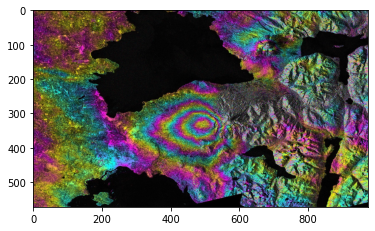

In [17]:
plt.imshow(image)

In [18]:
image.shape # h,w,c

(572, 974, 3)

In [19]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [20]:
# ROI
img_roi = image[100:200, 500:700]

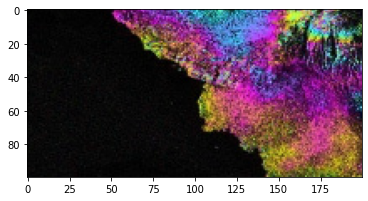

In [21]:
plt.imshow(img_roi)

In [22]:
b,g,r = cv2.split(image)

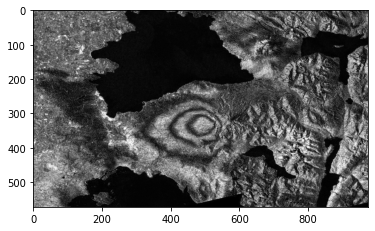

In [23]:
plt.imshow(b, cmap = 'gray')

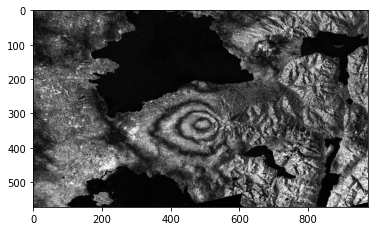

In [24]:
plt.imshow(g, cmap = 'gray')

In [25]:
# alternative approach
b = image[:,:,0]

In [26]:
import copy

image2 = copy.deepcopy(image)

In [27]:
image2[50:100,50:100] = [0,0,0]

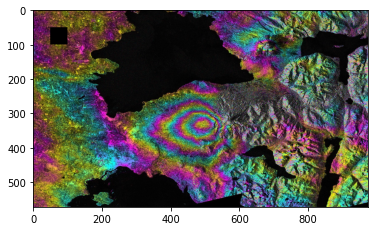

In [28]:
plt.imshow(image2)

In [29]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

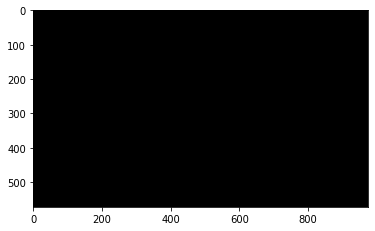

In [30]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [31]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [32]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [33]:
image_gray[0,0]

40

In [34]:
image_gray.shape

(572, 974)

In [35]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [36]:
image_hsv.shape

(572, 974, 3)

In [37]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [38]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [39]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [40]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [67]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

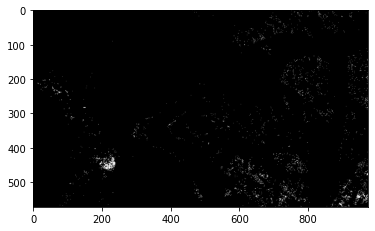

In [68]:
plt.imshow(thresh1, cmap='gray')

In [43]:
thresh1[thresh1==100].sum()

0

# Построение гистограммы

In [44]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

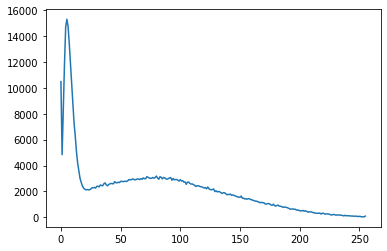

In [45]:
plt.plot(b_hist)

In [46]:
b_hist_cum = b_hist.cumsum()

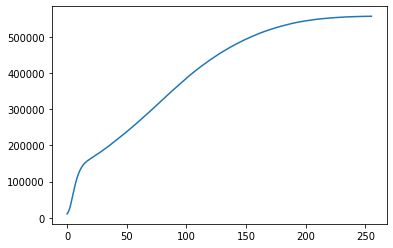

In [47]:
plt.plot(b_hist_cum)

In [49]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

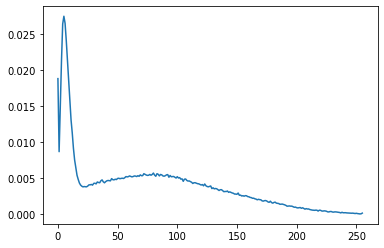

In [50]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [53]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


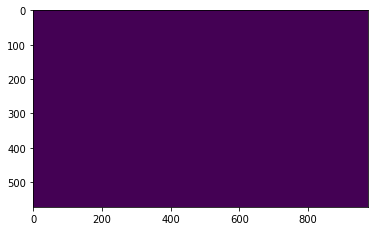

In [54]:
plt.imshow(diff)

In [55]:
mse = mean_squared_error(image_gray, image_gray)
mse

0.0

# Статистические характеристики изображений

In [56]:
mean = image_gray.mean()

In [57]:
std = image_gray.std()

In [58]:
print(mean,std)

67.41225535245043 52.016191875959635


In [60]:
eq_gray = cv2.equalizeHist(image_gray)

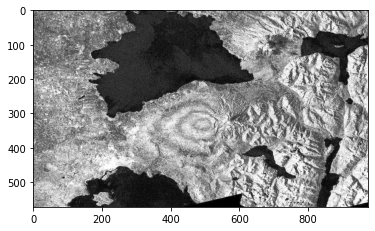

In [63]:
plt.imshow(eq_gray, cmap="gray")


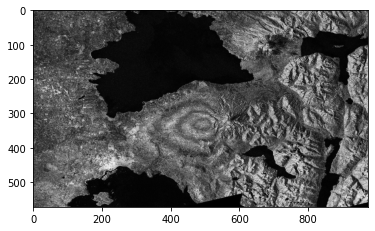

In [64]:
plt.imshow(image_gray, cmap="gray")

In [14]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


In [ ]:
                                        # 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.

Изображение успешно загружено
Размер изображения: (400, 600)


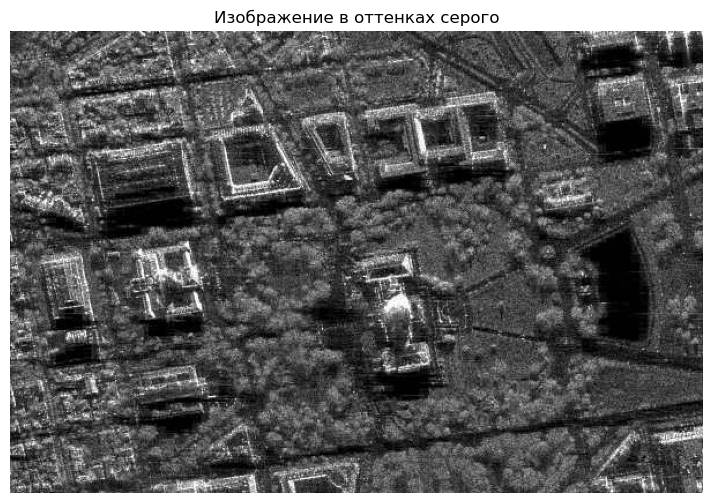

In [15]:
import cv2
import matplotlib.pyplot as plt


image_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)


if image_gray is None:
    print('Ошибка: файл sar_1_gray.jpg не найден')
else:
    print('Изображение успешно загружено')
    print('Размер изображения:', image_gray.shape)

    
    plt.figure(figsize=(10, 6))
    plt.imshow(image_gray, cmap='gray')
    plt.title('Изображение в оттенках серого')
    plt.axis('off')
    plt.show()

In [8]:
                                                     # 2. постройте гистограмму

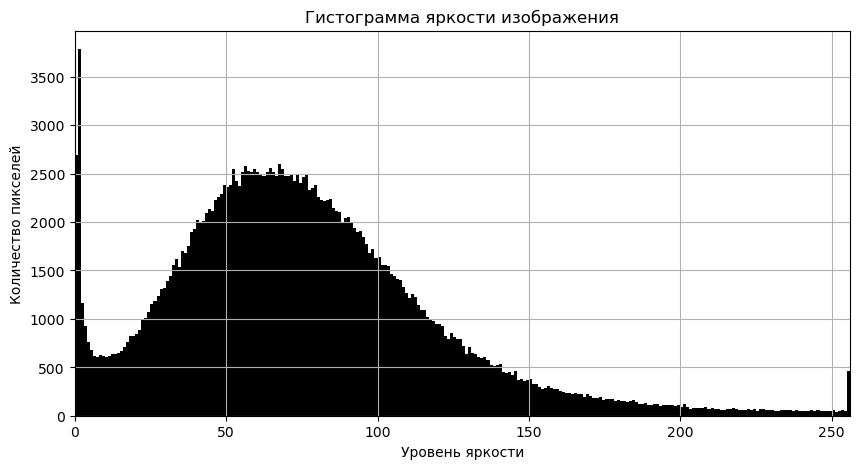

In [16]:

plt.figure(figsize=(10, 5))

plt.hist(image_gray.ravel(), bins=256, range=(0, 256), color='black')

plt.title('Гистограмма яркости изображения')
plt.xlabel('Уровень яркости')
plt.ylabel('Количество пикселей')
plt.xlim([0, 256])
plt.grid()

plt.show()

In [12]:
                                # 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1

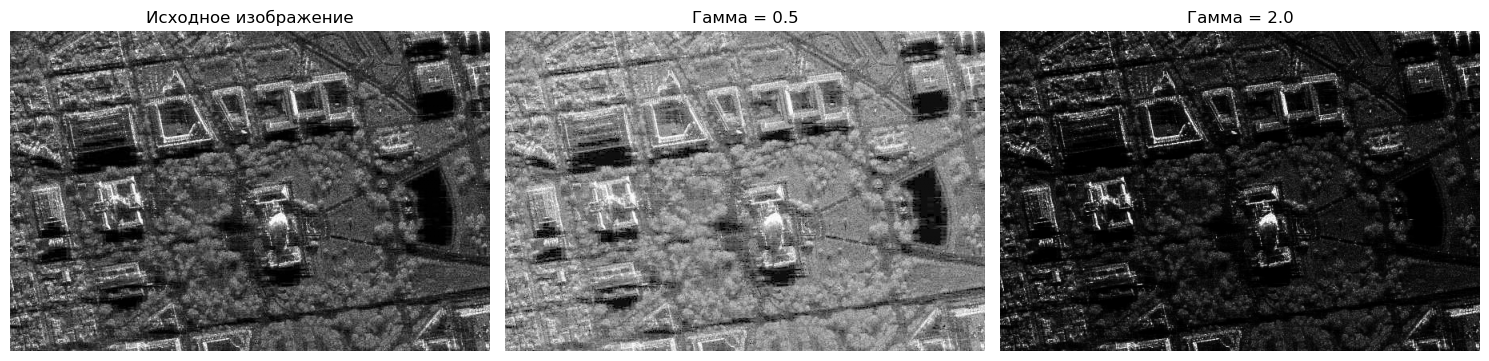

In [19]:
# 3. Гамма-коррекция изображения
import numpy as np


def gamma_correction(image, gamma):
    
    normalized = image / 255.0

    
    corrected = np.power(normalized, gamma)

    
    return np.uint8(corrected * 255)



image_gamma_less_1 = gamma_correction(image_gray, 0.5)


image_gamma_greater_1 = gamma_correction(image_gray, 2.0)



plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_gamma_less_1, cmap='gray')
plt.title('Гамма = 0.5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_gamma_greater_1, cmap='gray')
plt.title('Гамма = 2.0')
plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
                  # 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

In [24]:

from skimage.metrics import mean_squared_error, structural_similarity


mse_less_1 = mean_squared_error(image_gray, image_gamma_less_1)
ssim_less_1 = structural_similarity(
    image_gray,
    image_gamma_less_1,
    data_range=255
)


mse_greater_1 = mean_squared_error(image_gray, image_gamma_greater_1)
ssim_greater_1 = structural_similarity(
    image_gray,
    image_gamma_greater_1,
    data_range=255
)

print('Гамма = 0.5')
print('MSE:', mse_less_1)
print('SSIM:', ssim_less_1)

print('\nГамма = 2.0')
print('MSE:', mse_greater_1)
print('SSIM:', ssim_greater_1)

Гамма = 0.5
MSE: 3250.429145833333
SSIM: 0.7875008686792752

Гамма = 2.0
MSE: 2383.7636375
SSIM: 0.5270459922820343


In [25]:
                     # 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.

Исходное изображение:
Среднее: 74.94157083333333
Стандартное отклонение: 43.658465466227916

eq_gray:
Среднее: 127.02563333333333
Стандартное отклонение: 74.26964841889017

Скорректированное изображение:
Среднее: 123.1181375
Стандартное отклонение: 65.3025763098039


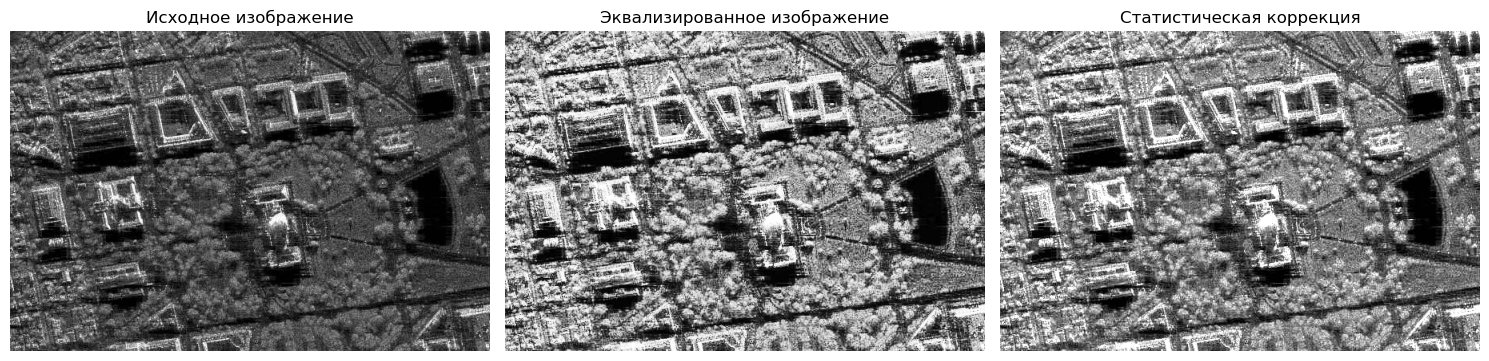

In [27]:


eq_gray = cv2.equalizeHist(image_gray)


mean_original = image_gray.mean()
std_original = image_gray.std()

mean_eq = eq_gray.mean()
std_eq = eq_gray.std()


corrected_stat = (
    (image_gray - mean_original) *
    (std_eq / std_original) +
    mean_eq
)


corrected_stat = np.clip(corrected_stat, 0, 255).astype(np.uint8)


print('Исходное изображение:')
print('Среднее:', mean_original)
print('Стандартное отклонение:', std_original)

print('\neq_gray:')
print('Среднее:', mean_eq)
print('Стандартное отклонение:', std_eq)

print('\nСкорректированное изображение:')
print('Среднее:', corrected_stat.mean())
print('Стандартное отклонение:', corrected_stat.std())


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title('Эквализированное изображение')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(corrected_stat, cmap='gray')
plt.title('Статистическая коррекция')
plt.axis('off')

plt.tight_layout()
plt.show()

In [28]:
                 # 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

Порог: 50
Белых пикселей: 169178
Чёрных пикселей: 70822

Порог: 100
Белых пикселей: 55653
Чёрных пикселей: 184347

Порог: 150
Белых пикселей: 13083
Чёрных пикселей: 226917

Порог: 200
Белых пикселей: 3830
Чёрных пикселей: 236170



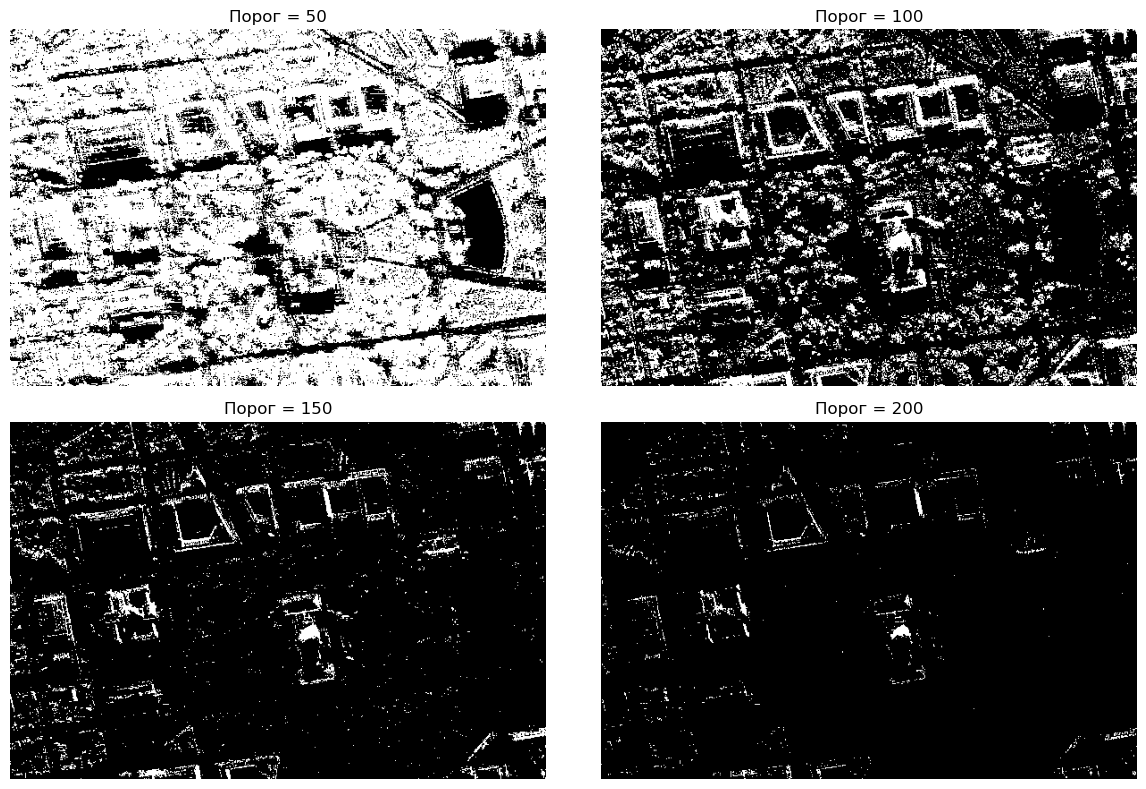

In [32]:

thresholds = [50, 100, 150, 200]

results = []

for threshold in thresholds:
    _, result = cv2.threshold(
        image_gray,
        threshold,
        255,
        cv2.THRESH_BINARY
    )
    results.append(result)

    
    white_pixels = np.sum(result == 255)
    black_pixels = np.sum(result == 0)

    print(f'Порог: {threshold}')
    print(f'Белых пикселей: {white_pixels}')
    print(f'Чёрных пикселей: {black_pixels}')
    print()



plt.figure(figsize=(12, 8))

for i in range(len(thresholds)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(results[i], cmap='gray')
    plt.title(f'Порог = {thresholds[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()